<a href="https://colab.research.google.com/github/jaiaakash5607/machine-learning/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
data=pd.read_csv("/content/1553768847-housing.csv")

In [20]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,INLAND,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,INLAND,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,INLAND,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,INLAND,84700


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [22]:
data.dropna(inplace=True)

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  int64  
 3   total_rooms         20433 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  int64  
 6   households          20433 non-null  int64  
 7   median_income       20433 non-null  float64
 8   ocean_proximity     20433 non-null  object 
 9   median_house_value  20433 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.7+ MB


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
x=data.drop(['median_house_value'],axis=1)
y=data['median_house_value']

In [26]:
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.2)

In [27]:
train_data=x_train.join(y_train)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
7756,-118.12,33.91,35,1518,279.0,857,251,3.6917,<1H OCEAN,197500
10119,-117.92,33.94,30,2506,394.0,1255,421,4.7813,<1H OCEAN,198200
20157,-119.15,34.44,33,2005,392.0,1043,351,5.3080,<1H OCEAN,297900
6112,-117.90,34.13,32,1640,391.0,1312,358,2.6292,<1H OCEAN,136100
18382,-121.83,37.23,7,5389,903.0,2232,825,6.6659,<1H OCEAN,500001
...,...,...,...,...,...,...,...,...,...,...
8603,-118.38,33.88,27,3039,606.0,1421,564,5.5771,<1H OCEAN,345500
10135,-117.91,33.91,24,2249,379.0,1015,385,4.9766,<1H OCEAN,267100
3810,-118.47,34.21,34,2512,603.0,1805,584,2.9735,<1H OCEAN,220000
13789,-117.62,34.44,6,8884,1687.0,3767,1334,3.5990,INLAND,140200


<Axes: >

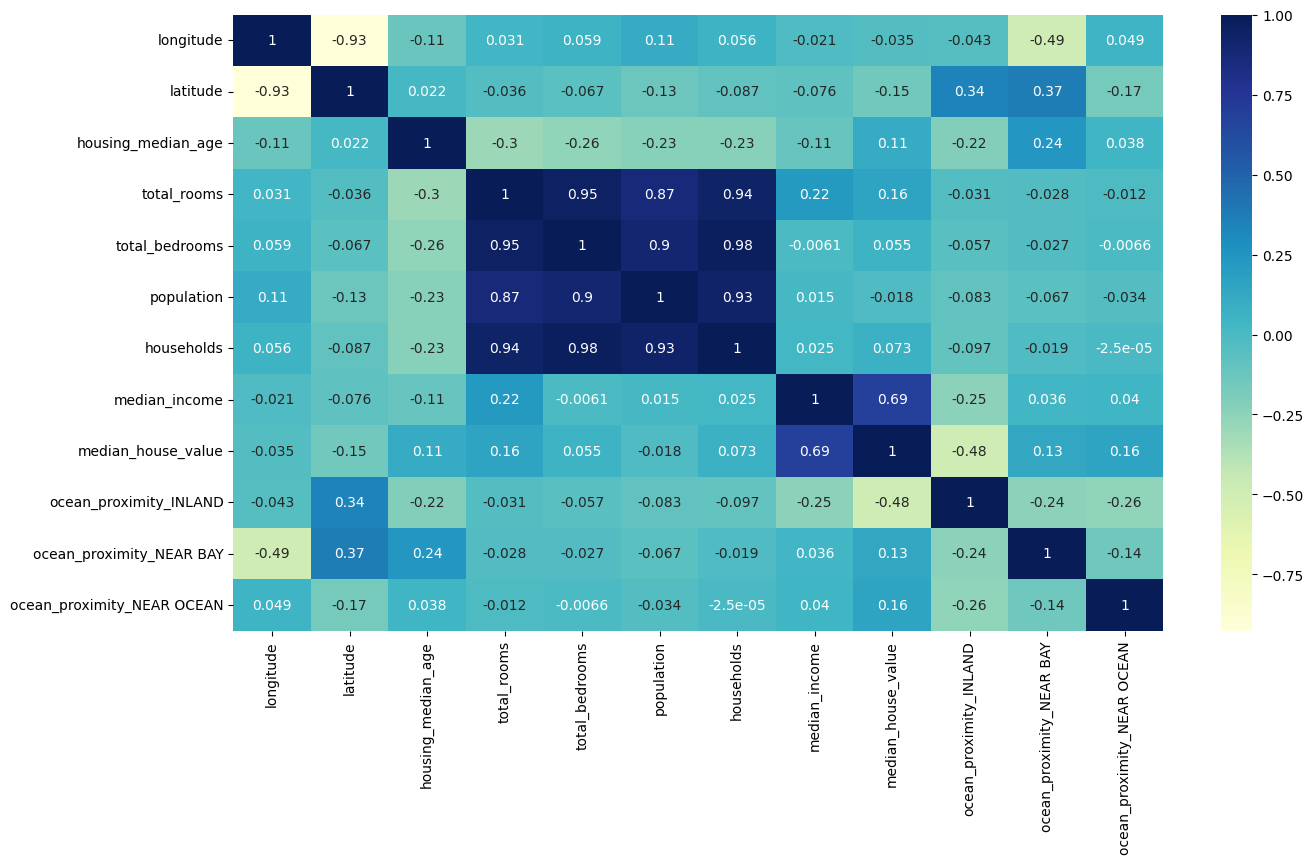

In [32]:
plt.figure(figsize=(15,8))
train_data = pd.get_dummies(train_data, columns=['ocean_proximity'], drop_first=True)
sns.heatmap(train_data.corr(),annot=True,cmap="YlGnBu")

In [60]:
x_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
7756,-118.12,33.91,35,2.119360,1.892327,2.048287,1.876320,3.6917,False,False,False
10119,-117.92,33.94,30,2.177797,1.942889,2.096260,1.952319,4.7813,False,False,False
20157,-119.15,34.44,33,2.152215,1.942162,2.073274,1.926237,5.3080,False,False,False
6112,-117.90,34.13,32,2.128596,1.941796,2.101701,1.929101,2.6292,False,False,False
18382,-121.83,37.23,7,2.260961,2.054999,2.164598,2.043373,6.6659,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
8603,-118.38,33.88,27,2.199401,2.002632,2.111403,1.992906,5.5771,False,False,False
10135,-117.91,33.91,24,2.165468,1.937326,2.069849,1.939581,4.9766,False,False,False
3810,-118.47,34.21,34,2.178068,2.001963,2.139933,1.997636,2.9735,False,False,False
13789,-117.62,34.44,6,2.311755,2.131951,2.222925,2.103730,3.5990,True,False,False


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

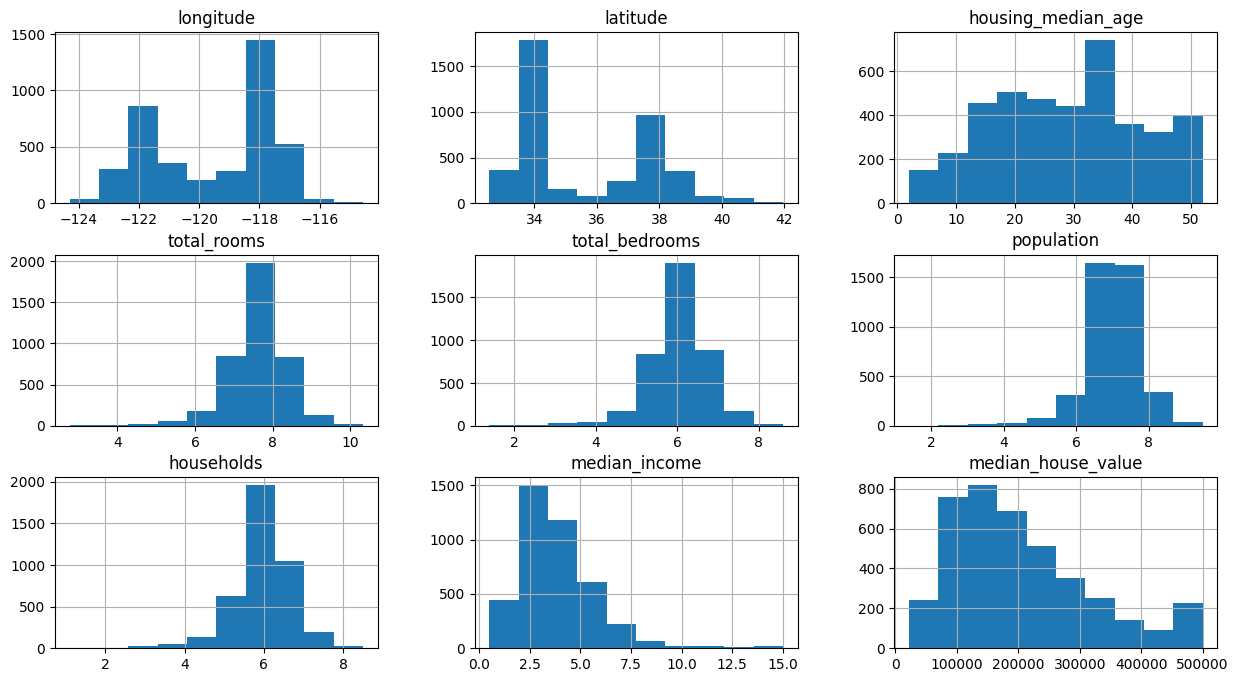

In [33]:
train_data.hist(figsize=(15,8))

In [34]:
train_data['total_bedrooms']=np.log(train_data['total_bedrooms']+1)
train_data['total_rooms']=np.log(train_data['total_rooms']+1)
train_data['population']=np.log(train_data['population']+1)
train_data['households']=np.log(train_data['households']+1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

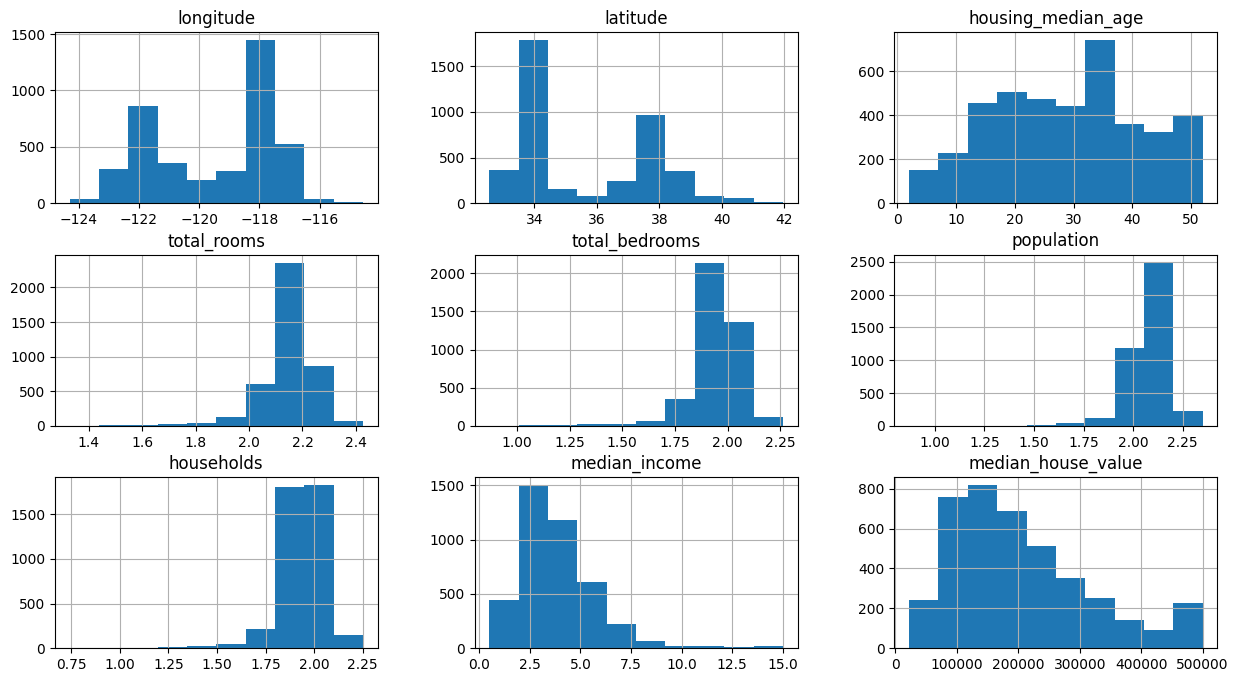

In [35]:
train_data.hist(figsize=(15,8))

In [36]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
7756,-118.12,33.91,35,2.119360,1.892327,2.048287,1.876320,3.6917,197500,False,False,False
10119,-117.92,33.94,30,2.177797,1.942889,2.096260,1.952319,4.7813,198200,False,False,False
20157,-119.15,34.44,33,2.152215,1.942162,2.073274,1.926237,5.3080,297900,False,False,False
6112,-117.90,34.13,32,2.128596,1.941796,2.101701,1.929101,2.6292,136100,False,False,False
18382,-121.83,37.23,7,2.260961,2.054999,2.164598,2.043373,6.6659,500001,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8603,-118.38,33.88,27,2.199401,2.002632,2.111403,1.992906,5.5771,345500,False,False,False
10135,-117.91,33.91,24,2.165468,1.937326,2.069849,1.939581,4.9766,267100,False,False,False
3810,-118.47,34.21,34,2.178068,2.001963,2.139933,1.997636,2.9735,220000,False,False,False
13789,-117.62,34.44,6,2.311755,2.131951,2.222925,2.103730,3.5990,140200,True,False,False


<Axes: xlabel='longitude', ylabel='latitude'>

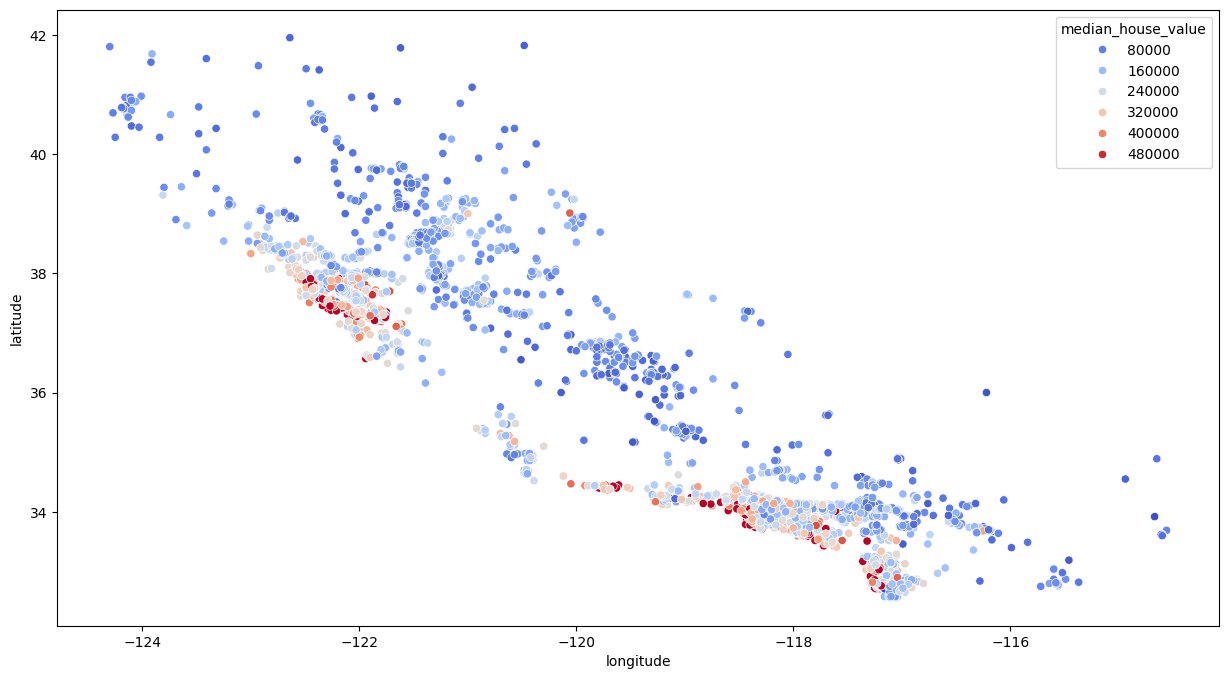

In [38]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='longitude',y='latitude',hue='median_house_value',data=train_data,palette='coolwarm')

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [68]:
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)

In [69]:
reg=LinearRegression()
reg.fit(x_train_s,y_train)

LinearRegression()

In [71]:
print(test_data.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN',
       'median_house_value'],
      dtype='object')


In [73]:
test_data=x_test.join(y_test)

test_data['total_bedrooms']=np.log(test_data['total_bedrooms']+1)
test_data['total_rooms']=np.log(test_data['total_rooms']+1)
test_data['population']=np.log(test_data['population']+1)
test_data['households']=np.log(test_data['households']+1)


In [74]:
x_test

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
6856,-118.16,34.06,25,8.362876,6.609349,7.679714,6.553933,6.1509,False,False,False,False
20257,-119.16,34.20,35,7.688913,6.456770,8.161946,6.436150,1.9704,False,False,False,True
17263,-119.71,34.42,23,7.634821,6.490724,7.549083,6.347389,2.5506,False,False,False,False
12869,-121.38,38.71,7,8.485290,6.841615,7.957877,6.811244,3.9318,True,False,False,False
2679,-115.53,32.99,25,7.855157,6.453625,7.641564,6.338594,1.7159,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
19191,-122.70,38.45,47,6.807935,5.043425,5.739793,4.976734,3.9766,False,False,False,False
4542,-118.20,34.03,52,6.369901,5.062595,6.594413,5.164786,1.4115,False,False,False,False
11182,-117.94,33.82,34,7.206377,5.361292,6.517671,5.308268,3.8828,False,False,False,False
7240,-118.11,34.01,41,6.704414,5.533389,6.654153,5.446737,2.2847,False,False,False,False


In [75]:
reg.score(x_train_s,y_train)

0.6498206936498254